In [1]:
file_read = "004_fit_MPAA"
file_write = "006_coefs_MPAA"

In [2]:
import polars as pl

df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
n_features_min = 9

In [4]:
df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features_min)

In [5]:
df_coefs_

backbone_test,n_features,alpha,2_zero,3_zero,4_zero,6_zero,7_zero,9_zero,12_zero,14_zero,16_zero,18_zero,19_zero,21_zero,46_zero,68_zero,91_zero,148_zero,157_zero,161_zero,232_zero,234_zero,235_zero,237_zero,240_zero,247_zero,252_zero,255_zero,270_zero,271_zero,275_zero,293_zero,324_zero,327_zero,355_zero,357_zero,415_zero,442_zero,465_zero,469_zero,494_zero,505_zero,506_zero,507_zero,519_zero,538_zero,540_zero,543_zero,575_zero,597_zero,602_zero,605_zero,642_zero
i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,9,3.2,-0.176747,null,null,0.278257,0.284923,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.339609,null,null,null,null,null,null,null,null,null,null,null,-0.580913,null,null,null,null,null,-0.085828,null,null,null,null,null,null,null,0.278966,0.472298,null,null,-0.515412,null,null
1,9,3.63,null,null,null,0.293002,0.305213,-0.330261,null,null,null,null,null,null,null,null,null,null,-0.274454,null,-0.146699,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.116248,null,null,null,-0.380448,null,null,null,0.273505,null,null,-0.247546,null,null,null
2,9,0.01,null,null,null,0.281937,null,0.007717,null,null,null,null,null,null,null,null,null,null,null,null,-0.198067,0.358571,null,null,null,null,null,null,null,null,null,null,-0.636663,null,null,null,-0.00328,null,0.393732,null,null,null,-0.819262,null,null,null,0.532223,null,null,null,null,null,null
3,9,0.01,null,null,null,null,0.709661,null,null,null,null,null,null,null,null,0.249499,null,null,null,null,-0.314889,null,null,null,-0.472343,null,null,null,null,0.737262,null,null,-0.639323,null,null,null,null,null,null,-0.901163,null,null,null,null,null,null,-0.143395,0.48025,null,null,null,null,null
4,9,0.01,-0.522033,null,null,null,0.335149,null,null,null,null,null,null,null,null,null,null,null,-0.978712,null,null,0.419692,null,null,-0.145812,null,null,null,null,0.517998,null,null,-0.111255,null,null,null,null,null,null,-0.505164,null,null,null,null,null,null,null,0.508074,null,null,null,null,null
5,9,0.23,null,null,null,0.286563,0.118811,-0.340267,null,null,null,null,0.193922,null,null,null,null,null,-0.111113,null,-0.247112,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.525806,null,null,null,null,0.407742,null,-0.438598,null,null,null
19,9,0.01,null,null,null,null,null,-0.318982,0.240413,null,null,null,null,null,null,null,-0.278695,null,null,null,null,0.428167,null,null,-1.004707,null,null,null,null,0.937222,null,null,-0.222631,null,null,null,null,null,null,null,null,null,-0.376213,null,null,null,null,0.394461,null,null,null,null,null
20,9,27.05,null,-0.170448,null,null,null,null,null,null,null,null,null,null,null,null,-0.18796,null,null,null,null,0.193529,null,null,null,null,null,0.11003,null,null,null,0.110035,null,null,null,null,null,null,null,null,null,null,-0.097925,null,null,null,null,0.219915,0.256502,-0.209613,null,null,null


In [6]:
columns_feat = [column for column in df_coefs_.columns if "zero" in column]

In [7]:
data = df_coefs_[columns_feat].to_numpy()

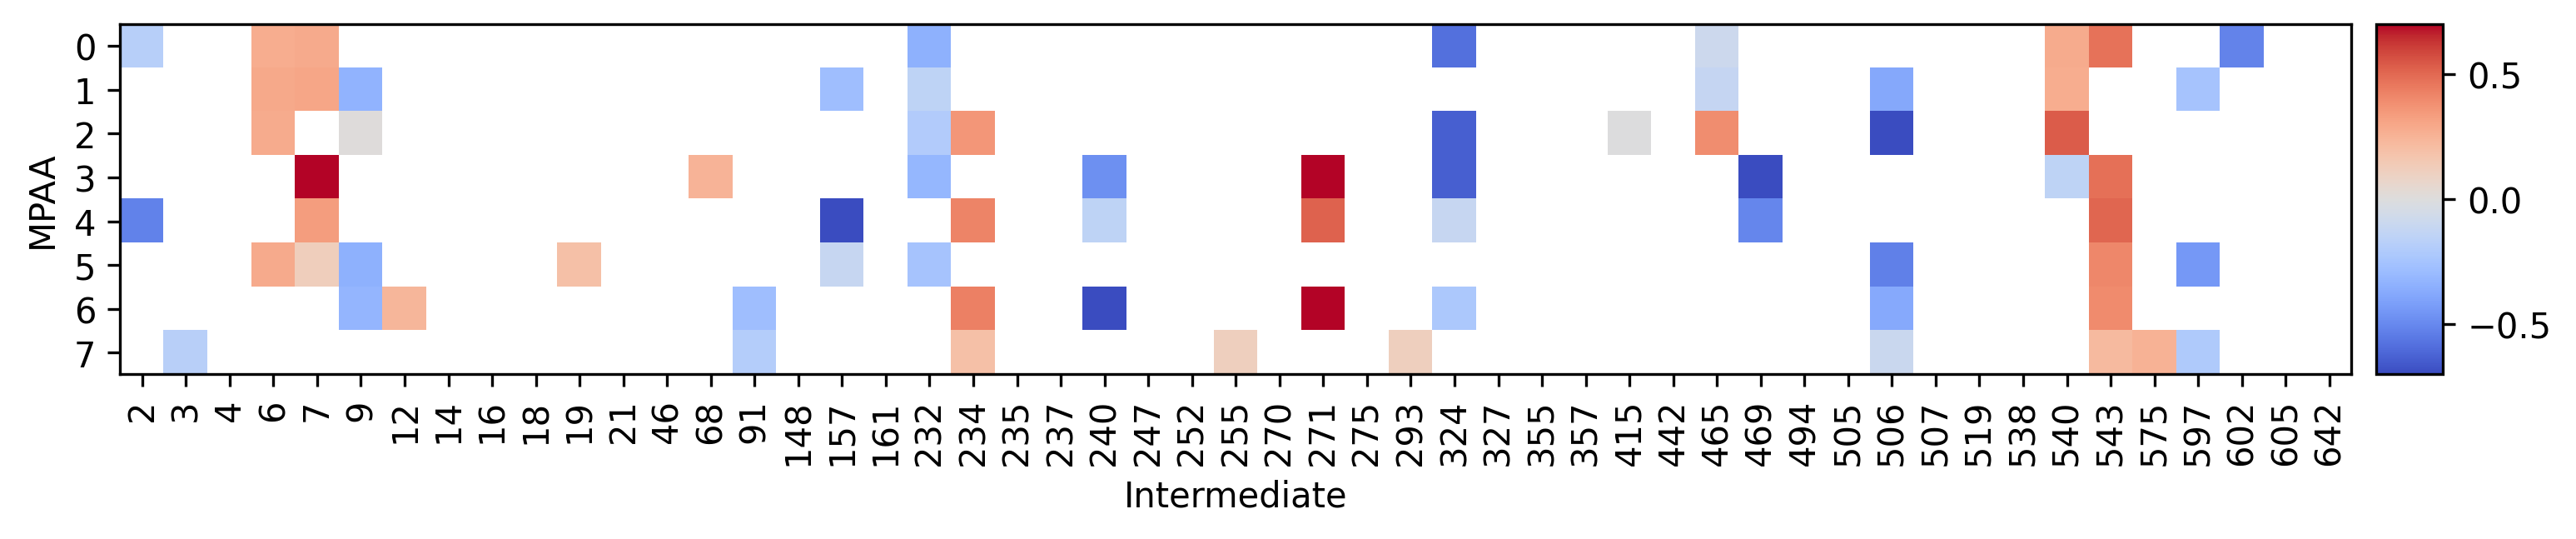

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

im = ax.imshow(data, vmin=-0.7, vmax=0.7, cmap="coolwarm")

ax.set_xlabel("Intermediate")
ax.set_ylabel("MPAA")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.set_yticklabels(np.arange(data.shape[0]))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [9]:
data_mean = df_coefs_[columns_feat].fill_null(0.0).mean().to_numpy().ravel()
data_std = df_coefs_[columns_feat].fill_null(0.0).std(ddof=1).to_numpy().ravel()
data_std = np.where(data_std == 0.0, np.nan, data_std)

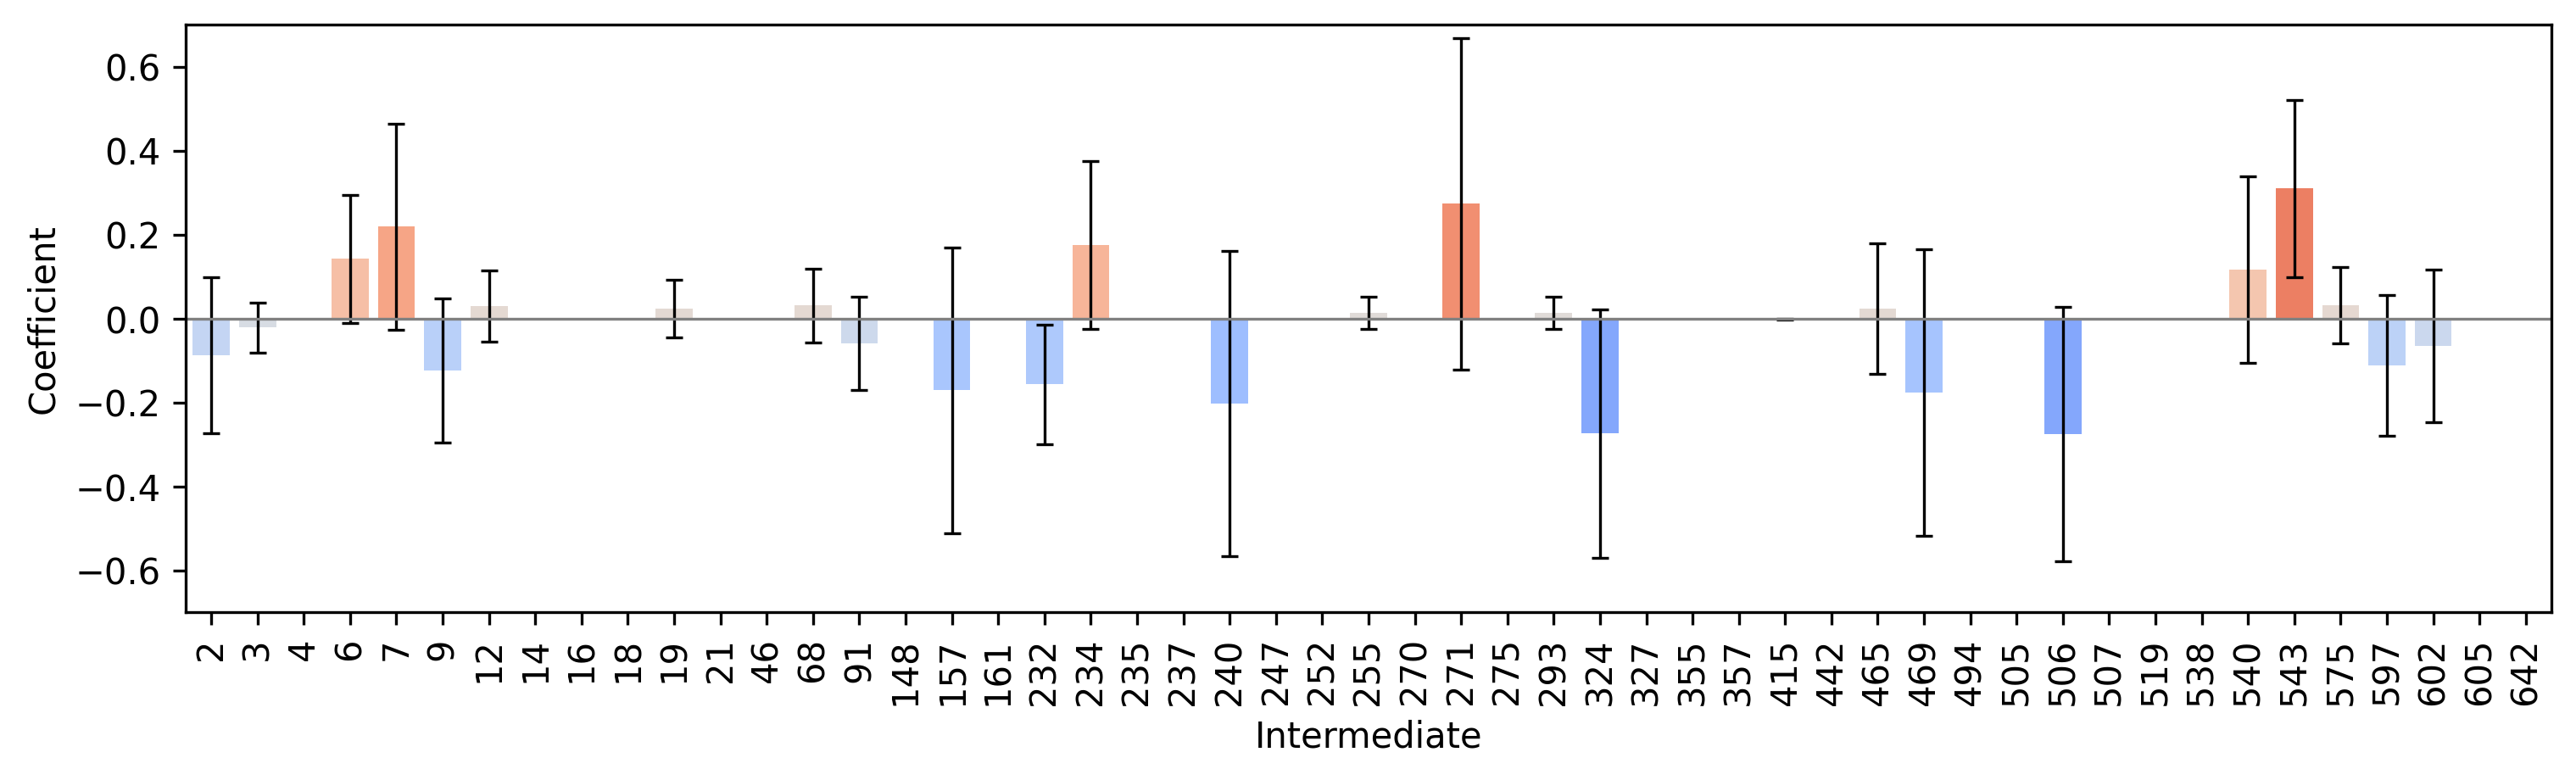

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.5, vmax=0.5)
colors = plt.cm.coolwarm(norm(data_mean))
error_kw = dict(elinewidth=0.8, capthick=0.8)
ax.bar(
    np.arange(len(data_mean)),
    data_mean,
    yerr=data_std,
    color=colors,
    capsize=2.5,
    error_kw=error_kw
)
ax.axhline(0, color="gray", linewidth=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Coefficient")
ax.set_xticks(np.arange(len(data_mean)))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.margins(x=0.003)
ax.set_ylim(-0.7, 0.7)

plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()